#Visualization of Food Delivery Dataset

NOTE: observations are written below respective code cells

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/IDRA/Day14_Food_Delivery_Visualization_Dataset.csv")
df.head()

,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


In [3]:
print("Shape = ", df.shape, "\n")
print(df.info())
print("\nAny null values?: ", df.isnull().values.any())
print("\nAny duplicate values?: ", df.duplicated().values.any())

Shape =  (360, 16) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_Batch_ID           360 non-null    object 
 1   Date                     360 non-null    object 
 2   Month                    360 non-null    object 
 3   Day                      360 non-null    object 
 4   City                     360 non-null    object 
 5   Cuisine                  360 non-null    object 
 6   Order_Channel            360 non-null    object 
 7   Weather                  360 non-null    object 
 8   Orders                   360 non-null    int64  
 9   Average_Order_Value      360 non-null    float64
 10  Revenue                  360 non-null    float64
 11  Marketing_Spend          360 non-null    float64
 12  Discounts                360 non-null    float64
 13  Avg_Delivery_Minutes     360 non-null    float64
 14  Custo

In [4]:
df.columns

Index(['Order_Batch_ID', 'Date', 'Month', 'Day', 'City', 'Cuisine',
       'Order_Channel', 'Weather', 'Orders', 'Average_Order_Value', 'Revenue',
       'Marketing_Spend', 'Discounts', 'Avg_Delivery_Minutes',
       'Customer_Rating', 'Repeat_Customer_Percent'],
      dtype='object')

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order_Batch_ID           360 non-null    object        
 1   Date                     360 non-null    datetime64[ns]
 2   Month                    360 non-null    object        
 3   Day                      360 non-null    object        
 4   City                     360 non-null    object        
 5   Cuisine                  360 non-null    object        
 6   Order_Channel            360 non-null    object        
 7   Weather                  360 non-null    object        
 8   Orders                   360 non-null    int64         
 9   Average_Order_Value      360 non-null    float64       
 10  Revenue                  360 non-null    float64       
 11  Marketing_Spend          360 non-null    float64       
 12  Discounts                360 non-nul

,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


#Changes in Orders over Time using Line Plot

combining the data according to the dates, i.e., if multiple rows contain the same date, they are combined

In [6]:
df['Date'].nunique()

222

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

df['Date'] = df['Date'].dt.date

daily = df.groupby('Date').agg({
    'Orders': 'sum',
    'Revenue': 'sum'
}).reset_index()

daily = daily.sort_values('Date')

daily.shape

(222, 3)

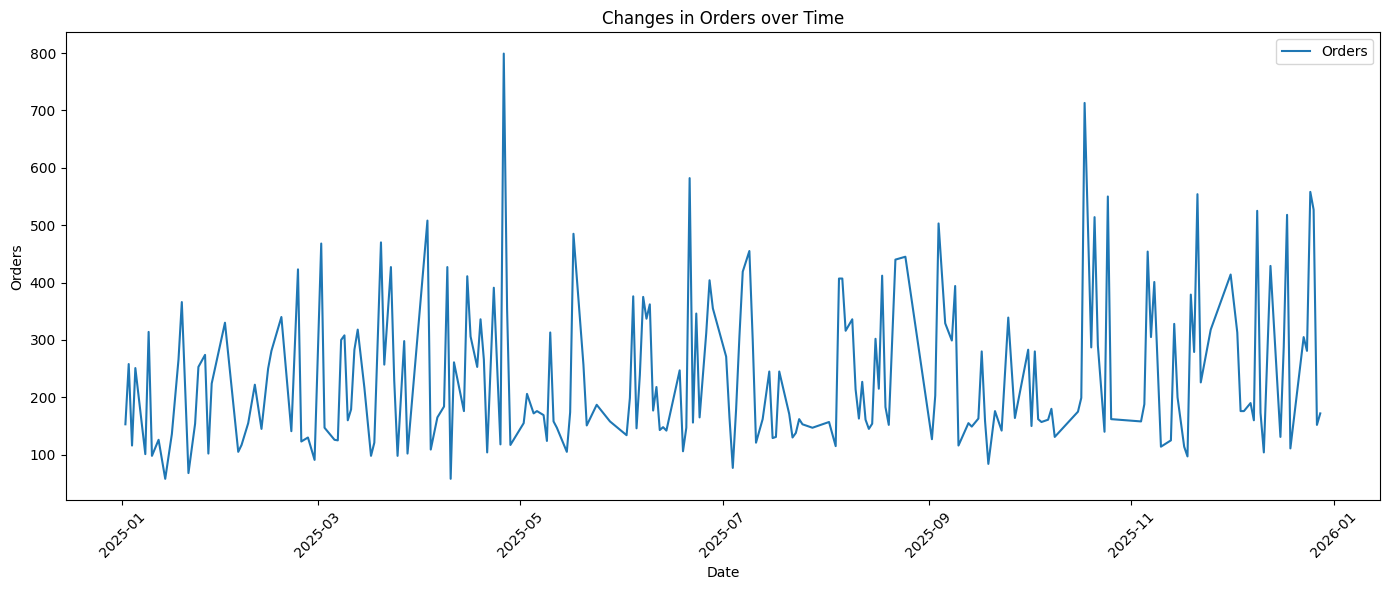

In [8]:
plt.figure(figsize=(14,6))
plt.plot(daily['Date'], daily['Orders'], label='Orders')
plt.legend()
plt.title('Changes in Orders over Time')
plt.xlabel('Date')
plt.ylabel('Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

in the year 2025
- Most orders were taken during the month of April
- second most orders were taken during October


#Changes in Revenue over Time using Line Plot

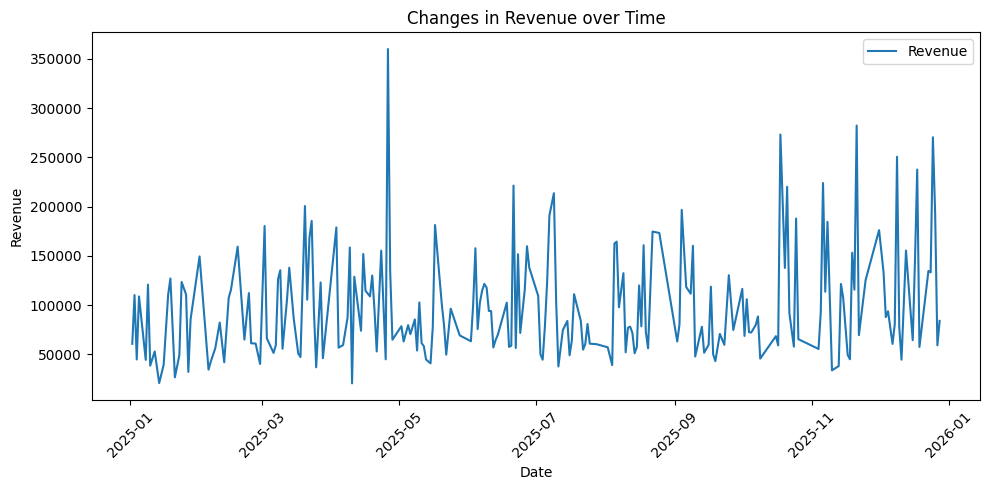

In [9]:
plt.figure(figsize=(10,5))
plt.plot(daily['Date'], daily['Revenue'], label='Revenue')
plt.legend()
plt.title("Changes in Revenue over Time")
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

in the year 2025
- most revenue generated was during the month of April
- in the month of November, revenue generated was second highest

#Difference between Cities in terms of Performance using Bar Chart

To check the performance, we can use *revenue*, *profit* or *orders* as the y label. For this task, I am using *revenue* as y label

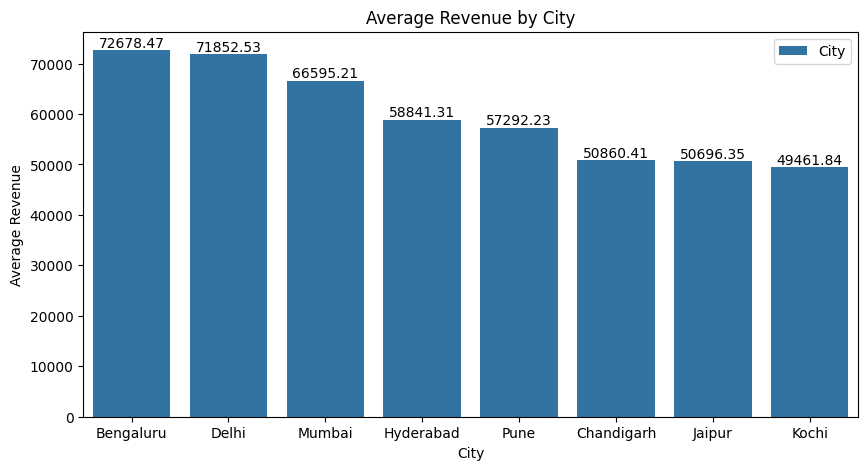

In [10]:
city_rev = df.groupby('City')['Revenue'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(x='City', y='Revenue', data=city_rev, label='City')
plt.title('Average Revenue by City')
plt.xlabel('City')
plt.ylabel('Average Revenue')
plt.legend()
for index, row in city_rev.iterrows():
    plt.text(row.name, row.Revenue, round(row.Revenue, 2), color='black', ha="center", va="bottom")
plt.show()

- Bengaluru is the highest revenue generating city
- Kochi is the least revenue generating city
- Chandigrah and Jaipur produces roughly the same revenu (just a small difference between them, compared to the other city pairs)

#Difference between Cuisines in terms of Performance using Bar Chart

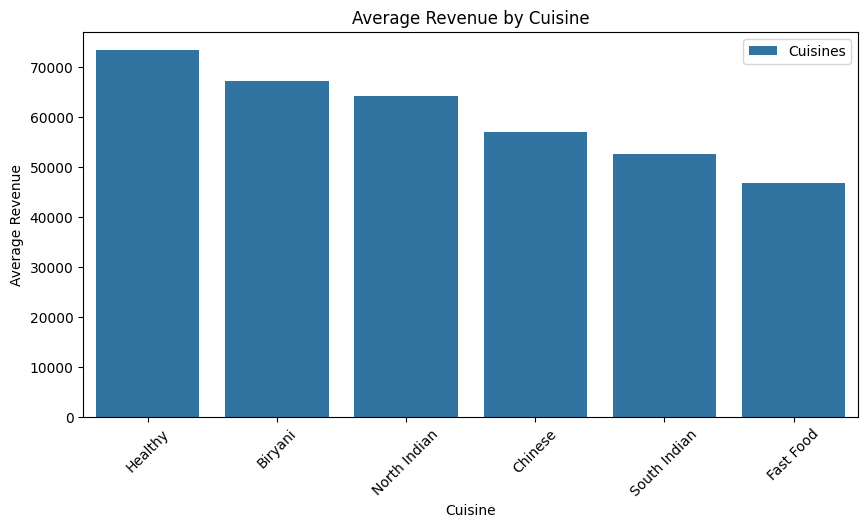

In [11]:
cuisine_rev = df.groupby('Cuisine')['Revenue'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(x='Cuisine', y='Revenue', data=cuisine_rev, label='Cuisines')
plt.title('Average Revenue by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Average Revenue')
plt.xticks(rotation=45)
plt.legend()
plt.show()

- Healthy cuisine is the most popular
- Fast food is the least popular cuisine
- North Indian cuisine is more preferred than South Indian cuisine

#Relationship between Marketing Spend & Revenue using Scatter plot

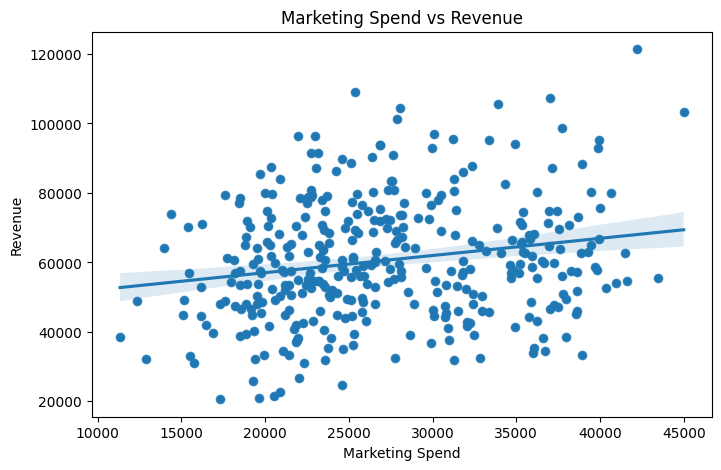


Correlation between Marketing spend and Revenue:  0.19812719039135182


In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='Marketing_Spend', y='Revenue')
sns.regplot(data=df, x='Marketing_Spend', y='Revenue')

plt.title('Marketing Spend vs Revenue')
plt.xlabel('Marketing Spend')
plt.ylabel('Revenue')
plt.show()

print("\nCorrelation between Marketing spend and Revenue: ", df['Marketing_Spend'].corr(df['Revenue']))

Marketing spend and Revenue show a weak but positive relationship.

As marketing spend increases, the revenue tends to increase slightly. But the points are scattered very widely, showing that marketing spend alone cannot explain the variations in revenue

#Relation between Delivery Time & Customer Rating using Scatter Plot

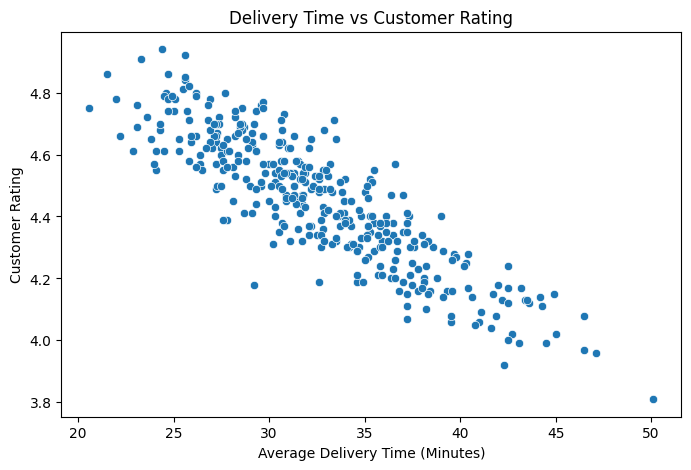


Correlation between Delivery Time and Customer Rating:  -0.8758810555011177


In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Avg_Delivery_Minutes',
    y='Customer_Rating'
)

plt.title('Delivery Time vs Customer Rating')
plt.xlabel('Average Delivery Time (Minutes)')
plt.ylabel('Customer Rating')
plt.show()

print("\nCorrelation between Delivery Time and Customer Rating: ", df['Avg_Delivery_Minutes'].corr(df['Customer_Rating']))

The scatter plot has a downward slope towards the right.

The correlation score between the average delivery time and customer rating is a negative value.

After analysing the scatter plot and correlation score, it can be understood that the average delivery time and customer rating has a negative relationship, so, the more it takes to delivery, the less the customer rates the restaurant.   

#Analysing the Effect of Weather on Performance using Bar Plot

In [14]:
df['Weather'].unique()
df['Weather'].value_counts()

,count
Weather,
Clear,146
Cloudy,94
Rainy,75
Hot,45


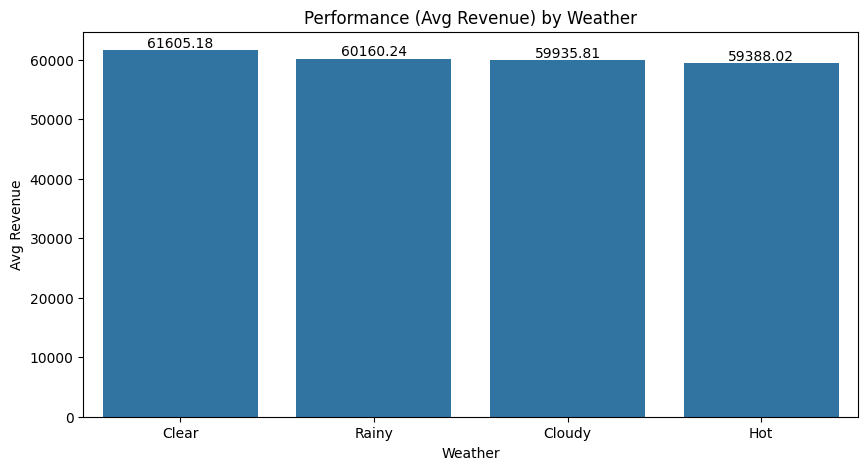

In [15]:
weather_rev = df.groupby('Weather')['Revenue'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,5))

sns.barplot(data=weather_rev, x='Weather', y='Revenue')

plt.title('Performance (Avg Revenue) by Weather')
plt.xlabel('Weather')
plt.ylabel('Avg Revenue')

for index,row in weather_rev.iterrows():
  plt.text(row.name, row.Revenue, round(row.Revenue, 2), ha='center', va='bottom')

plt.show()

It can be observed that the revenue cannot be distinctly separated according to the weather, as there is only slight difference between each weather.
- The highest revenue generated was during the clear weather
- The lowest revenue generated was during the hot weather
- The difference between the clear and the hot weather is  2217.16 currency only

#Analysing the Effect of Order Channels on Performance using Count Plot

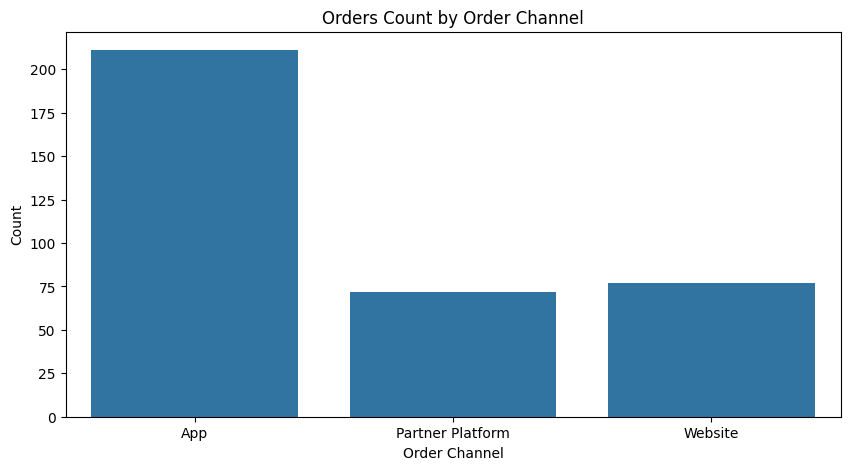

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Order_Channel')
plt.title('Orders Count by Order Channel')
plt.xlabel('Order Channel')
plt.ylabel('Count')
plt.show()

Mostly, the customers use the restaurant app to order.

The website and partner platform is used comparatively less, with the website being slightly more used

#Distribution of Orders using Histogram

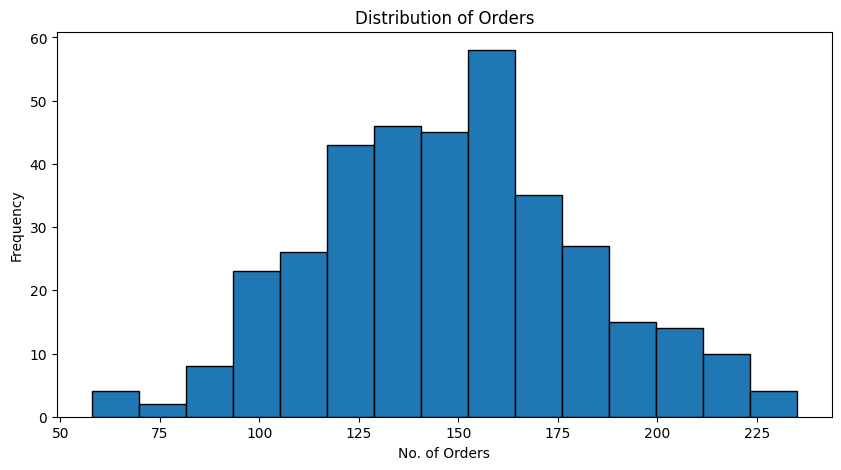

In [17]:
plt.figure(figsize=(10,5))
plt.hist(df['Orders'], bins=15, edgecolor='black')
plt.title('Distribution of Orders')
plt.xlabel('No. of Orders')
plt.ylabel('Frequency')
plt.show()

The number of orders is mainly concentrated between approx. 120 and 180
- highest frequency: between 150 and 160 approx.
- least frequency: between 60 and 80 approx.

#Understanding Revenue using Box Plot

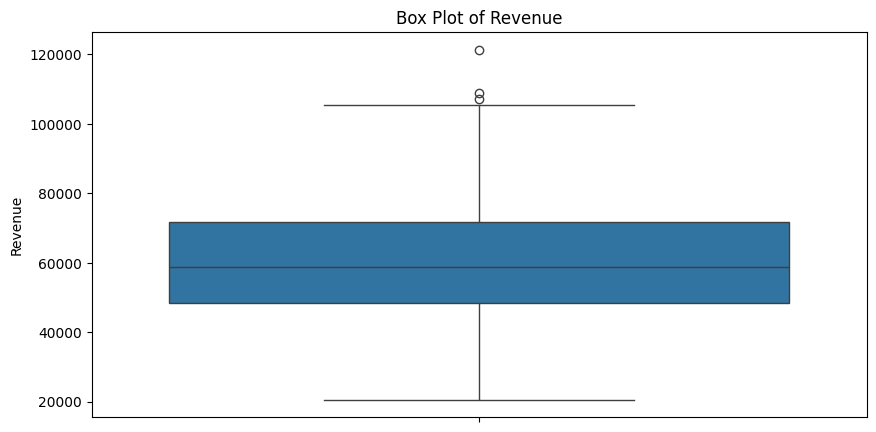

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, y='Revenue')
plt.title('Box Plot of Revenue')
plt.ylabel('Revenue')
plt.show()

Observations of this plot (in currency; all the values here are approximations)
- Median (the midline): 60,000
- Q1 (lower edge of the box): 50,000
- Q3 (upper edge of the box): 70,000

There are some outliers past the uppwe whisker, indicating some days achieved unusually high revenue

#Relation between Customer Rating and Order Channel using Violin Plot

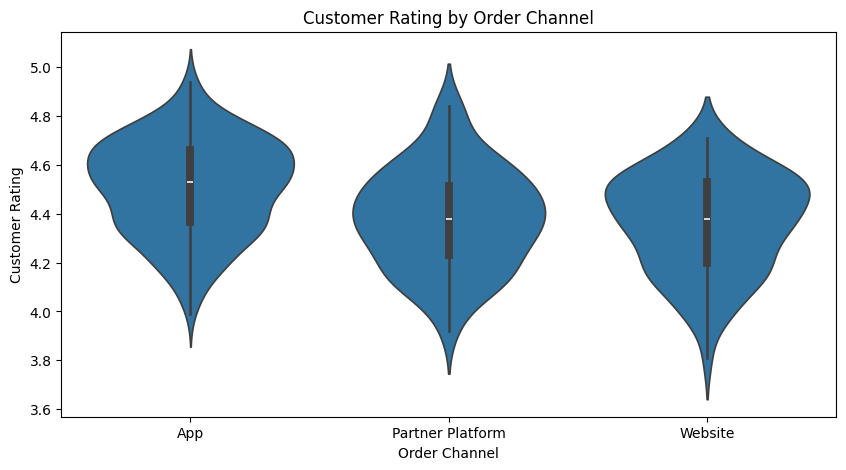

In [19]:
plt.figure(figsize=(10,5))
sns.violinplot(data=df, x='Order_Channel', y='Customer_Rating')
plt.title('Customer Rating by Order Channel')
plt.xlabel('Order Channel')
plt.ylabel('Customer Rating')
plt.show()

Customer rating is generally higher in all three channels (> 4.2)

- App users have slightly higher ratings (approx. 4.5)
- Partner platform and website users have slightly lower ratings, compared to that of App (approx. 4.4)

Though the ratings vary across different channels, all channels maintain relatively high customer rating

#Correlation Heatmap

In [20]:
numeric_col = df.select_dtypes(include=np.number)
numeric_col

,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9
...,...,...,...,...,...,...,...,...
355,173,345.70,54617.02,23218.25,3545.94,34.0,4.38,32.7
356,84,368.12,43172.89,36244.79,7910.39,27.6,4.39,42.6
357,148,431.35,67272.24,18853.98,6147.45,41.1,4.09,30.2
358,179,483.13,88272.94,38950.88,13430.03,30.5,4.64,49.0


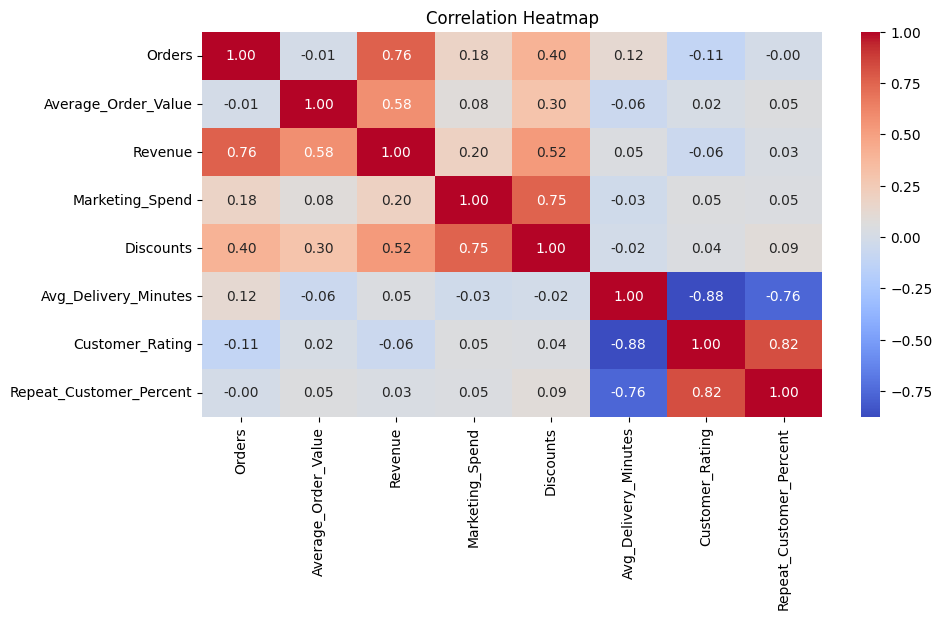

In [21]:
corr = numeric_col.corr()

plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Observations from the correlation heatmap
- the highest correlation is between customer rating and repeat_customer_percent (**0.82**), indicating higher the rating, more likely the customers to come back to the restaurant
- there is higher correlation between revenue and orders (**0.76**), indicating as the orders increase, the revenue generally tends to increase
- the lowest correlation is between the customer rating and average delivery time (**-0.88**), that shows the more time taken for delivery, the lower the rating given
- the number of customers coming back to the restaurant is negatively impacted by the delivery time taken, which is shown with the correlation score of **-0.76**

#Summary
Observations such as the following were made:
- Business performance varied across time and locations, with certain months and cities consistently showing stronger revenue and order performance than others.
- Order volume was a major driver of revenue, as indicated by the strong positive correlation between Orders and Revenue (0.76).
- Customer satisfaction was strongly connected to delivery performance and retention. Longer delivery times were associated with lower ratings (-0.88) and fewer repeat customers (-0.76), while higher ratings were associated with higher repeat-customer percentages (0.82).
- Marketing spend had only a weak positive relationship with revenue (0.20), suggesting that spending more on marketing does not necessarily result in proportionally higher revenue.
- External factors such as weather had relatively little influence on revenue, since average revenue remained fairly similar across weather conditions.
- The restaurant's App was the dominant ordering channel, while customer ratings remained relatively high across all channels.

Overall, the analysis suggests that increasing order volume and improving delivery efficiency and customer satisfaction are more strongly associated with business performance than marketing spend or weather conditions.